In [2]:
# Imports for the project
# Same general setup I have used in past assignments

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random


import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import TensorDataset, DataLoader

#make results more reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.19MB/s]


Train size: 60000
Test size:  10000
One image shape: torch.Size([1, 28, 28])


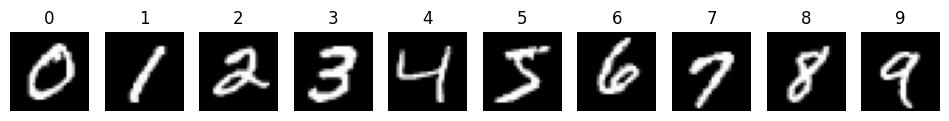

In [3]:
# Load MNIST through torchvision so I do not need to download a CSV
# ToTensor() also scales the pixel values from 0-255 down to 0-1 for me
transform = T.Compose([T.ToTensor()])

train_dataset_full = torchvision.datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset       = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Print the shapes so I can make sure everything loaded correctly
# Each image is 1 x 28 x 28 (grayscale, 28 by 28 pixels)
print("Train size:", len(train_dataset_full))
print("Test size: ", len(test_dataset))
print("One image shape:", train_dataset_full[0][0].shape)

# Show one example of each digit so I can confirm the labels look right
fig, axes = plt.subplots(1, 10, figsize=(12, 1.8))
for digit in range(10):
    # Find the first image whose label is the digit I am looking for
    for i in range(len(train_dataset_full)):
        if train_dataset_full[i][1] == digit:
            img = train_dataset_full[i][0]
            break
    axes[digit].imshow(img.squeeze(), cmap='gray')
    axes[digit].set_title(str(digit))
    axes[digit].axis('off')
plt.show()

In [4]:
# Split the training data into actual training data and validation data
# I use 20% for validation, same as I have done in past projects
n_total = len(train_dataset_full)
n_val   = int(0.2 * n_total)
n_train = n_total - n_val

train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED)
)

# DataLoader breaks the data into batches
# shuffle=True so the model does not see the data in the same order every epoch
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))

Train batches: 750
Val batches:   188
Test batches:  157


In [5]:
# Small CNN for MNIST
# Two convolution layers and one fully connected layer
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(CNN, self).__init__()

        # First convolution layer
        # Input: 1 x 28 x 28
        # Output: 16 x 28 x 28
        # padding=1 keeps the width and height the same
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=3, padding=1)

        # Batch normalization layer
        # This helps the model learn more stable and not change too much between batches
        self.bn1 = nn.BatchNorm2d(16)

        # Max pooling layer
        # This reduces the image size by half each time
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolution layer
        # Input: 16 x 14 x 14
        # Output: 32 x 14 x 14
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Batch normalization layer
        # Again helps keep the values more stable during training
        self.bn2 = nn.BatchNorm2d(32)

        # Dropout layer
        # Randomly turns off some neurons during training so other neurons can't rely on the strong ones too much
        self.dropout = nn.Dropout(0.4)

        # Fully connected layer
        # After 2 pooling layers:
        # 28x28 -> 14x14 -> 7x7
        # Final shape = 32 x 7 x 7
        # Flattened = 32 * 7 * 7 = 1568
        self.fc1 = nn.Linear(32 * 7 * 7, 64)

        # Final output layer
        # This gives the final class scores (10 classes for digits 0-9)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # First conv + ReLU
        x = F.relu(self.bn1(self.conv1(x)))
        # 16 x 28 x 28 -> 16 x 14 x 14
        x = self.pool(x)

        # Second conv + ReLU
        x = F.relu(self.bn2(self.conv2(x)))
        # 32 x 14 x 14 -> 32 x 7 x 7
        x = self.pool(x)

        # Flatten into one long vector
        x = x.reshape(x.shape[0], -1)

        # Apply dropout before the fully connected layer
        x = self.dropout(x)

        # First fully connected layer
        x = F.relu(self.fc1(x))

        # Final output layer (gives class scores)
        x = self.fc2(x)

        return x

In [6]:
# Create the CNN model
# 1 input channel because MNIST is grayscale, 10 classes for digits 0-9
model = CNN(in_channels=1, num_classes=10)

# CrossEntropyLoss is used for multi-class classification problems
cel = nn.CrossEntropyLoss()

# opitimize
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epoch: 0, Loss: 181.6164, Val accuracy: 0.9749
epoch: 1, Loss: 69.4053, Val accuracy: 0.9821
epoch: 2, Loss: 52.6106, Val accuracy: 0.9844
epoch: 3, Loss: 46.1610, Val accuracy: 0.9856
epoch: 4, Loss: 39.4403, Val accuracy: 0.9875


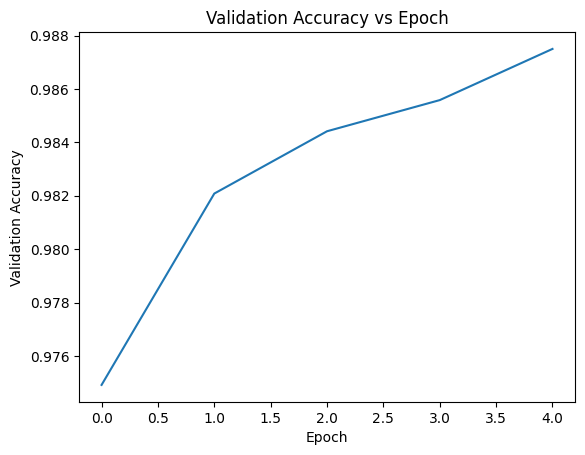

In [7]:
# use cpu for device
device = torch.device("cpu")
model = model.to(device)

num_epochs = 5
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    curr_loss = 0.0

    # Training loop
    for images, labels in train_loader:
        images = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # get rid of old graidents
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)
        # Compute loss
        loss = cel(outputs, labels)
        # Backward pass
        loss.backward()

        optimizer.step()

        curr_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.long)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = correct / total
    train_losses.append(curr_loss)
    val_accuracies.append(val_accuracy)
    print(f"epoch: {epoch}, Loss: {curr_loss:.4f}, Val accuracy: {val_accuracy:.4f}")

# plot accuracy in each epoch
plt.figure()
plt.plot(val_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.show()

In [8]:
# Evaluate the trained model on the clean MNIST test set
# This is the baseline accuracy before I start changing the input data
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

clean_accuracy = correct / total
print(f"Clean MNIST test accuracy: {clean_accuracy:.4f}")

Clean MNIST test accuracy: 0.9885


Clean MNIST test accuracy:        0.9885
Rotated (60 deg) test accuracy:  0.2493
Drop in accuracy: 0.7392


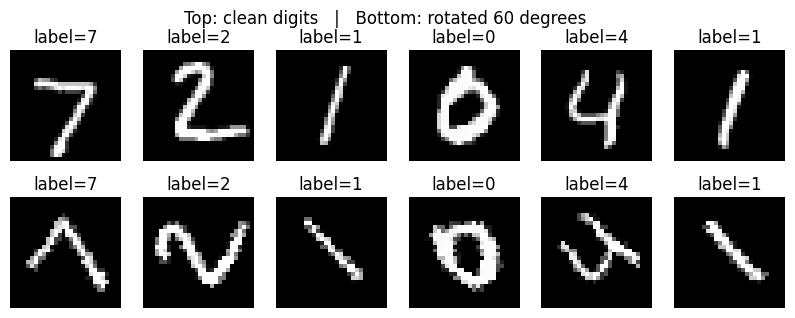

In [9]:
# Sanity check: rotate every test image by 60 degrees and see what the accuracy does
# If the model is using shortcut features specific to upright digits, the accuracy should drop a lot
# even though the digits are still readable to a human
ROTATION_ANGLE = 60

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        # Rotate each image in the batch
        # TF.rotate works on individual tensors so I stack them back into a batch
        images = torch.stack([TF.rotate(img, ROTATION_ANGLE) for img in images])

        images = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

rotated_accuracy = correct / total
print(f"Clean MNIST test accuracy:        {clean_accuracy:.4f}")
print(f"Rotated ({ROTATION_ANGLE} deg) test accuracy:  {rotated_accuracy:.4f}")
print(f"Drop in accuracy: {(clean_accuracy - rotated_accuracy):.4f}")

# Plot a few examples so I can visually compare clean vs rotated
fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
for i in range(6):
    img, label = test_dataset[i]
    rot_img = TF.rotate(img, ROTATION_ANGLE)

    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f"label={label}")
    axes[0, i].axis('off')

    axes[1, i].imshow(rot_img.squeeze(), cmap='gray')
    axes[1, i].set_title(f"label={label}")
    axes[1, i].axis('off')
plt.suptitle(f"Top: clean digits   |   Bottom: rotated {ROTATION_ANGLE} degrees")
plt.show()

angle: 0 deg, accuracy: 0.9885
angle: 15 deg, accuracy: 0.9576
angle: 30 deg, accuracy: 0.7882
angle: 45 deg, accuracy: 0.5294
angle: 60 deg, accuracy: 0.2493
angle: 75 deg, accuracy: 0.1577
angle: 90 deg, accuracy: 0.1447


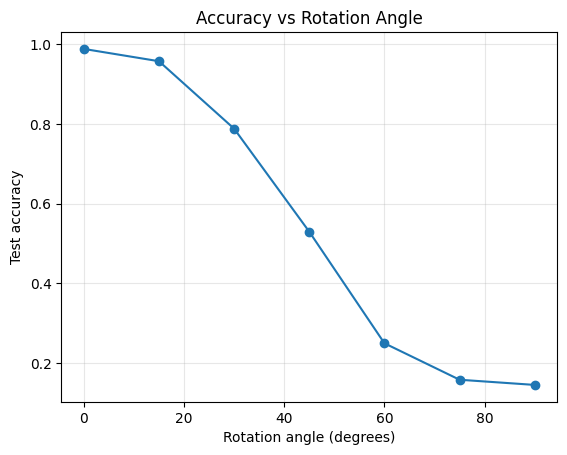

In [10]:
# Full rotation sweep
# I rotate the entire test set by each angle and re-evaluate the model
# This shows the trend instead of just one angle like before
angles = [0, 15, 30, 45, 60, 75, 90]
rotation_accuracies = []

for angle in angles:
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            # Rotate every image in the batch
            images = torch.stack([TF.rotate(img, angle) for img in images])

            images = images.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.long)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    rotation_accuracies.append(acc)
    print(f"angle: {angle} deg, accuracy: {acc:.4f}")

# Plot accuracy vs angle
plt.figure()
plt.plot(angles, rotation_accuracies, marker='o')
plt.xlabel("Rotation angle (degrees)")
plt.ylabel("Test accuracy")
plt.title("Accuracy vs Rotation Angle")
plt.grid(True, alpha=0.3)
plt.show()

noise std: 0.00, accuracy: 0.9885
noise std: 0.10, accuracy: 0.9807
noise std: 0.20, accuracy: 0.8299
noise std: 0.30, accuracy: 0.5158
noise std: 0.50, accuracy: 0.2262
noise std: 0.75, accuracy: 0.1299
noise std: 1.00, accuracy: 0.1175


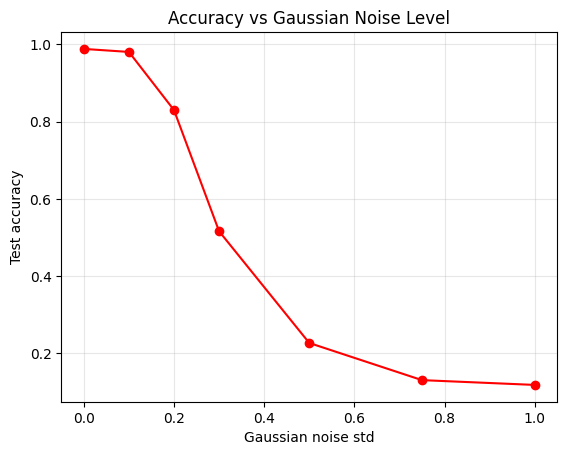

In [11]:
# Add Gaussian noise to the test images at different strengths
# I clamp to [0, 1] after adding noise so the values stay in the right range
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
noise_accuracies = []

for std in noise_levels:
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            # Add random Gaussian noise to every image in the batch
            noise = torch.randn_like(images) * std
            images = torch.clamp(images + noise, 0.0, 1.0)

            images = images.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.long)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    noise_accuracies.append(acc)
    print(f"noise std: {std:.2f}, accuracy: {acc:.4f}")

# Plot accuracy vs noise level
plt.figure()
plt.plot(noise_levels, noise_accuracies, marker='o', color='red')
plt.xlabel("Gaussian noise std")
plt.ylabel("Test accuracy")
plt.title("Accuracy vs Gaussian Noise Level")
plt.grid(True, alpha=0.3)
plt.show()

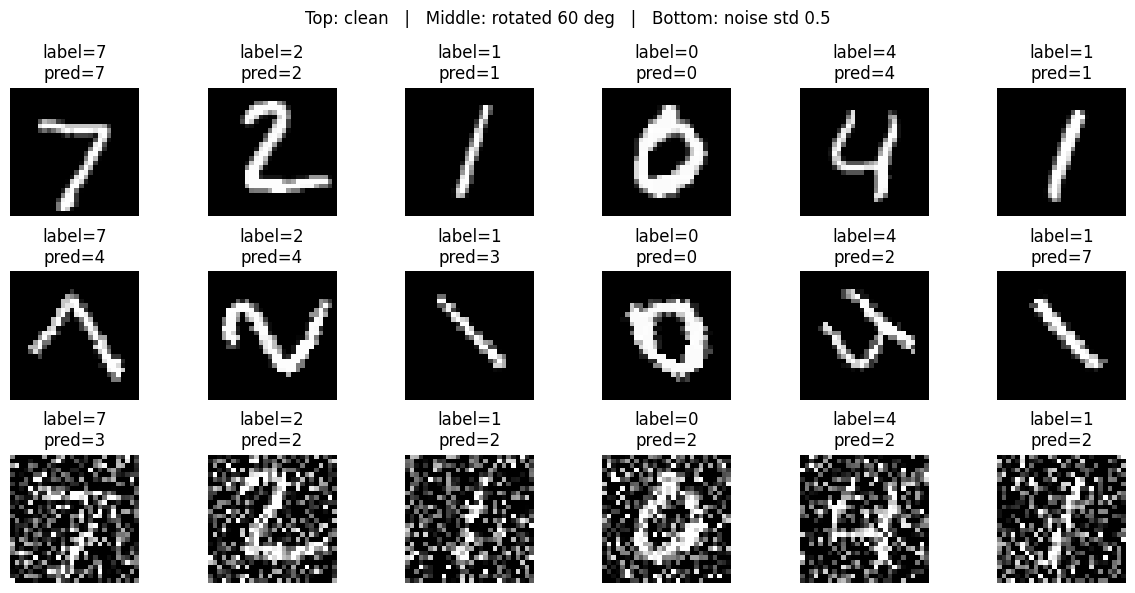

In [12]:
# Pick a few test images and show clean vs rotated vs noisy side by side
# Each one has the model's prediction printed above
n = 6
example_angle = 60
example_noise = 0.5

# Grab the first n test images
sample_images = []
sample_labels = []
for i in range(n):
    img, label = test_dataset[i]
    sample_images.append(img)
    sample_labels.append(label)

sample_images = torch.stack(sample_images)
sample_labels = torch.tensor(sample_labels)

# Make rotated and noisy versions
rotated_images = torch.stack([TF.rotate(img, example_angle) for img in sample_images])
noisy_images = torch.clamp(sample_images + torch.randn_like(sample_images) * example_noise, 0.0, 1.0)

# Get the model's predictions on each version
model.eval()
with torch.no_grad():
    pred_clean   = torch.max(model(sample_images.to(device, dtype=torch.float32)),   1)[1]
    pred_rotated = torch.max(model(rotated_images.to(device, dtype=torch.float32)), 1)[1]
    pred_noisy   = torch.max(model(noisy_images.to(device, dtype=torch.float32)),   1)[1]

# Plot three rows: clean, rotated, noisy
fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
for i in range(n):
    axes[0, i].imshow(sample_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"label={sample_labels[i].item()}\npred={pred_clean[i].item()}")
    axes[0, i].axis('off')

    axes[1, i].imshow(rotated_images[i].squeeze(), cmap='gray')
    axes[1, i].set_title(f"label={sample_labels[i].item()}\npred={pred_rotated[i].item()}")
    axes[1, i].axis('off')

    axes[2, i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[2, i].set_title(f"label={sample_labels[i].item()}\npred={pred_noisy[i].item()}")
    axes[2, i].axis('off')

plt.suptitle(f"Top: clean   |   Middle: rotated {example_angle} deg   |   Bottom: noise std {example_noise}")
plt.tight_layout()
plt.show()

In [13]:
# This second model sees rotated and noisy images during training
# If shortcut learning is the issue, this one should be more robust to the same perturbations
# I use a wrapper dataset that applies a random rotation and a little noise to every image

from torch.utils.data import Dataset

class AugmentedDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        # Random rotation between -90 and 90 degrees
        angle = float(np.random.uniform(-90, 90))
        img = TF.rotate(img, angle)
        # Random noise std between 0 and 0.3
        std = float(np.random.uniform(0.0, 0.3))
        img = torch.clamp(img + torch.randn_like(img) * std, 0.0, 1.0)
        return img, label

augmented_train_dataset = AugmentedDataset(train_dataset)
augmented_train_loader = DataLoader(augmented_train_dataset, batch_size=64, shuffle=True)

# New model, same architecture as before
model_aug = CNN(in_channels=1, num_classes=10).to(device)
cel_aug = nn.CrossEntropyLoss()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.0005)

num_epochs = 5
aug_train_losses = []
aug_val_accuracies = []

for epoch in range(num_epochs):
    model_aug.train()
    curr_loss = 0.0

    for images, labels in augmented_train_loader:
        images = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        optimizer_aug.zero_grad()
        outputs = model_aug(images)
        loss = cel_aug(outputs, labels)
        loss.backward()
        optimizer_aug.step()

        curr_loss += loss.item()

    # Quick validation check
    model_aug.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.long)
            outputs = model_aug(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    aug_train_losses.append(curr_loss)
    aug_val_accuracies.append(val_acc)
    print(f"epoch: {epoch}, Loss: {curr_loss:.4f}, Val accuracy: {val_acc:.4f}")

epoch: 0, Loss: 575.0589, Val accuracy: 0.9283
epoch: 1, Loss: 291.8216, Val accuracy: 0.9480
epoch: 2, Loss: 230.4514, Val accuracy: 0.9576
epoch: 3, Loss: 192.7971, Val accuracy: 0.9598
epoch: 4, Loss: 170.8075, Val accuracy: 0.9676


angle: 0 deg, augmented accuracy: 0.9683
angle: 15 deg, augmented accuracy: 0.9639
angle: 30 deg, augmented accuracy: 0.9651
angle: 45 deg, augmented accuracy: 0.9650
angle: 60 deg, augmented accuracy: 0.9639
angle: 75 deg, augmented accuracy: 0.9579
angle: 90 deg, augmented accuracy: 0.9115


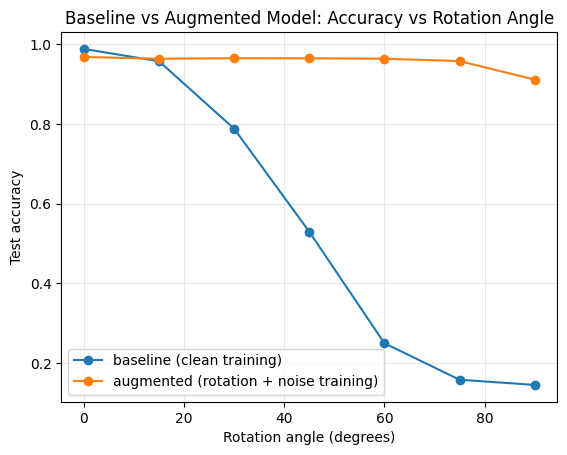


angle | baseline | augmented
    0 | 0.9885   | 0.9683
   15 | 0.9576   | 0.9639
   30 | 0.7882   | 0.9651
   45 | 0.5294   | 0.9650
   60 | 0.2493   | 0.9639
   75 | 0.1577   | 0.9579
   90 | 0.1447   | 0.9115


In [14]:
# Re-run the rotation sweep but this time also evaluate the augmented model
# If shortcut learning is really the issue, the augmented model should hold up much better
aug_rotation_accuracies = []

for angle in angles:
    model_aug.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = torch.stack([TF.rotate(img, angle) for img in images])
            images = images.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.long)

            outputs = model_aug(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    aug_rotation_accuracies.append(acc)
    print(f"angle: {angle} deg, augmented accuracy: {acc:.4f}")

# Plot both lines together
plt.figure()
plt.plot(angles, rotation_accuracies,     marker='o', label='baseline (clean training)')
plt.plot(angles, aug_rotation_accuracies, marker='o', label='augmented (rotation + noise training)')
plt.xlabel("Rotation angle (degrees)")
plt.ylabel("Test accuracy")
plt.title("Baseline vs Augmented Model: Accuracy vs Rotation Angle")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the side-by-side numbers too
print("\nangle | baseline | augmented")
for a, base, aug in zip(angles, rotation_accuracies, aug_rotation_accuracies):
    print(f"{a:>5} | {base:.4f}   | {aug:.4f}")